In [58]:
import sys
sys.path.append('..')


from dungeongame import DungeonGame
from dungeongame.model import Agent
import pandas as pd
from copy import deepcopy
from tqdm import tqdm
import matplotlib.pyplot as plt
import numpy as np
import os
import gc
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

sns.set_theme()

In [59]:
GAMESTATE_COLUMN_ORDER = ['rounds', 'phase_rounds', 'defeats',
       'points', 'deck_size', 'dungeon_size', 'adventurer_hp', 'has_armor',
       'has_shield', 'has_chalice', 'has_torch', 'has_vorpal', 'has_lance',
       'drew_goblin', 'drew_skeleton', 'drew_orc', 'drew_vampire',
       'drew_golem', 'drew_wraith', 'drew_demon', 'drew_dragon',
       'Goblin_taken', 'Skeleton_taken', 'Orc_taken', 'Vampire_taken',
       'Golem_taken', 'Wraith_taken', 'Demon_taken', 'Dragon_taken',
       'Goblin_added', 'Skeleton_added', 'Orc_added', 'Vampire_added',
       'Golem_added', 'Wraith_added', 'Demon_added', 'Dragon_added',
       'potential_damage', 'Armor_taken', 'Shield_taken', 'Chalice_taken',
       'Torch_taken', 'Vorpal Sword_taken', 'Lance_taken',
       'Opponent_1_defeats', 'Opponent_1_points', 'Opponent_1_has_passed', 'Opponent_1_is_alive',
       'Opponent_1_Armor', 'Opponent_1_Shield', 'Opponent_1_Chalice',
       'Opponent_1_Torch', 'Opponent_1_Vorpal Sword', 'Opponent_1_Lance',
       'Opponent_2_defeats', 'Opponent_2_points', 'Opponent_2_has_passed', 'Opponent_2_is_alive',
       'Opponent_2_Armor', 'Opponent_2_Shield', 'Opponent_2_Chalice',
       'Opponent_2_Torch', 'Opponent_2_Vorpal Sword', 'Opponent_2_Lance',
       'Opponent_3_defeats', 'Opponent_3_points', 'Opponent_3_has_passed', 'Opponent_3_is_alive',
       'Opponent_3_Armor', 'Opponent_3_Shield', 'Opponent_3_Chalice',
       'Opponent_3_Torch', 'Opponent_3_Vorpal Sword', 'Opponent_3_Lance']

ACTION_SPACE_COLUMN_ORDER =  ['draw', 'pass',
       'remove_armor', 'remove_shield', 'remove_chalice', 'remove_torch',
       'remove_vorpal', 'remove_lance', 'add_to_dungeon', 'target_goblin',
       'target_skeleton', 'target_orc', 'target_vampire', 'target_golem',
       'target_wraith', 'target_demon', 'target_dragon']

EXCLUDE_COLS = ['game_id', 'current_player', 'card_drawn', 'reward']

In [60]:
# utility functions
def parse_log_entry(log):
    log = deepcopy(log)
    log[0].update(log[1])
    log[0].update(log[2])
    return log[0]

def minmax_scaling(data, min_values=None, max_values=None):
    if min_values is None:
        min_values = data.min()
    if max_values is None:
        max_values = data.max()
    data = (data - min_values) / (max_values - min_values)
    return data, min_values, max_values

In [61]:
def get_players(mode="random"):
    players = [
    {
        "name": "Alan",
        "mode": mode,
    },
    {
        "name": "Jane",
        "mode": mode,
    },
    {
        "name": "Charlie",
        "mode": mode,
    },
    {
        "name": "Georgia",
        "mode": mode,
    }
    ]
    return players


def generate_training_data(num_games, player_mode='random', agent=None):
    players = get_players(player_mode)

    all_logs = []
    for count in range(num_games):
        count += 1
        game = DungeonGame(players=players, agent=agent, auto_run=True, log_game=True, verbose=False)
        game.run()
        logs = pd.DataFrame([parse_log_entry(log) for log in game.game_log])
        all_logs.append(logs)
    
    return pd.concat(all_logs).reset_index(drop=True)


def collect_stats(all_logs):
    """Compute per-checkpoint summary stats for training_log. Returns list:
    [avg_game_length, avg_total_points, avg_phase_round_pass,
     avg_add_to_dungeon_count, avg_total_reward]
    """
    all_logs = all_logs.copy()
    data = []

    game_lengths = all_logs.groupby('game_id')['rounds'].max()
    data.append(game_lengths.mean())

    final_scores = all_logs.groupby(['game_id', 'current_player']).tail(1)
    final_scores = final_scores.groupby('game_id')['points'].sum()
    data.append(final_scores.mean())

    data.append(all_logs[all_logs['pass'] == 1].phase_rounds.mean())

    data.append(all_logs[all_logs['add_to_dungeon'] == 1].groupby('game_id').size().mean())

    total_rewards = all_logs.groupby(['game_id'])['reward'].sum()
    data.append(total_rewards.mean())

    return data


### Generate the first round of training data

The starting dataset will be generated through random games played by four agents.

In [62]:
import glob

model_folders = glob.glob("../model/agent*")
if model_folders:
    version = max(int(f.split("agent")[1]) for f in model_folders)
    RESUME = True
    print(f"Resuming from agent{version}. Skipping quickstart.")
else:
    version = 0
    RESUME = False
    print("No existing model found. Running quickstart...")
    quickstart_logs = generate_training_data(25, "random")


Resuming from agent20000. Skipping quickstart.


## Train the first agent

In [63]:
def get_discounted_rewards(rewards, gamma=0.9):
    # Split into episodes at each non-zero reward (dungeon phase boundary),
    # then compute discounted returns within each episode independently.
    episodes, current = [], []
    for r in rewards:
        current.append(r)
        if r != 0:  # non-zero reward = end of this episode
            episodes.append(current)
            current = []
    if current:  # trailing actions with no reward yet (edge case)
        episodes.append(current)

    result = []
    for ep in episodes:
        ep_returns = np.zeros(len(ep), dtype=np.float32)
        running = 0.0
        for t in reversed(range(len(ep))):
            running = running * gamma + ep[t]
            ep_returns[t] = running
        result.extend(ep_returns)
    return np.array(result, dtype=np.float32)

def add_discounted_rewards(game_logs, gamma=0.9):
    # for each game_id and player combination
    # calculate the discounted rewards and add to the dataframe
    # the discounted_rewards must return to the dataframe in the same order
    # as the rewards

    game_logs = game_logs.copy()

    for game_id in game_logs['game_id'].unique():
        for player in game_logs['current_player'].unique():
            mask = (game_logs['game_id'] == game_id) & (game_logs['current_player'] == player)
            rewards = game_logs[mask]['reward'].values
            discounted_rewards = get_discounted_rewards(rewards, gamma)
            game_logs.loc[mask, 'discounted_reward'] = discounted_rewards

    return game_logs

In [64]:
def train_agent(agent, game_logs, min_feat_values=None, max_feat_values=None, gamma=0.9):
    global MAX_FEATURE_VALUES, MIN_FEATURE_VALUES

    game_logs = game_logs.copy()

    # prepare data
    # scale feature columns
    feature_data = game_logs.loc[:, GAMESTATE_COLUMN_ORDER].astype(np.float32)
    if min_feat_values is not None and max_feat_values is not None:
        game_logs.loc[:, GAMESTATE_COLUMN_ORDER], _, _ = minmax_scaling(feature_data, min_feat_values, max_feat_values)
    else:
        game_logs.loc[:, GAMESTATE_COLUMN_ORDER], MIN_FEATURE_VALUES, MAX_FEATURE_VALUES = minmax_scaling(feature_data)

    # add discounted rewards to the game logs
    game_logs = add_discounted_rewards(game_logs, gamma)

    states = game_logs[GAMESTATE_COLUMN_ORDER].values.astype(np.float32)
    actions = game_logs[ACTION_SPACE_COLUMN_ORDER].replace(-1, 0).values.astype(np.float32)
    rewards = game_logs['discounted_reward'].values

    policy_loss, value_loss = agent.train(states, actions, rewards)

    # warn if loss is nan
    if np.isnan(policy_loss) or np.isnan(value_loss):
        print('Loss is nan! Check the model')
            
    return agent, policy_loss, value_loss

In [65]:
agent = Agent(input_shape=(len(GAMESTATE_COLUMN_ORDER),), num_actions=len(ACTION_SPACE_COLUMN_ORDER), gamma=0.7)


In [ ]:
if not RESUME:
    agent, policy_loss_hist, value_loss_hist = train_agent(agent, quickstart_logs, gamma=0.7)
    if not os.path.exists(f"../model/agent{version}/"):
        os.makedirs(f"../model/agent{version}/")
    agent.save(f"../model/agent{version}/")

    print(MIN_FEATURE_VALUES, MAX_FEATURE_VALUES)
    print('Policy Loss:', float(policy_loss_hist))
    print('Value Loss:', float(value_loss_hist))

## The training loop

In [69]:
# version is set by the auto-detection above
num_iterations = 20000
num_games = 1
checkpoint_at = 200


In [70]:
version, num_iterations

(20000, 20000)

In [71]:
if RESUME:
    agent.load(f"../model/agent{version}/")
    print(f"Loaded agent{version}")
else:
    print("Starting with fresh agent (no pre-trained weights)")


Loaded agent20000


In [72]:
MAX_FEATURE_VALUES = np.array([37.,  6.,  1.,  1., 13., 34., 11.,  1.,  1.,  1.,  1.,  1.,  1.,
        1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  2.,  2.,  1.,  1.,  2.,
        1.,  1.,  1.,  2.,  2.,  2.,  2.,  2.,  1.,  1.,  1., 16.,  1.,
        1.,  1.,  1.,  1.,  1.,  2.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,
        1.,  1.,  2.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  2.,
        1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.,  1.], dtype=np.float32)

MIN_FEATURE_VALUES = np.array([1., 0., 0., 0., 0., 0., 3., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0.], dtype=np.float32)

In [73]:
policy_loss = []
value_loss = []

In [74]:
training_log_columns = ['game_lengths', 'total_points_per_game', 'phase_round_when_players_pass', 'number_of_times_players_added_to_dungeon', 'total_rewards_per_game', 'policy_loss', 'value_loss']
training_log = pd.DataFrame(columns=training_log_columns)

In [75]:
for i in tqdm(range(int(num_iterations))):
    # generate a new set of training data
    version += 1
    game_logs = generate_training_data(num_games, 'greedy', agent=agent)

    # train agent from the previous checkpoint
    agent, policy_loss_hist, value_loss_hist = train_agent(agent, game_logs,
                                                           MIN_FEATURE_VALUES,
                                                           MAX_FEATURE_VALUES, gamma=0.7)
    
    if version % checkpoint_at == 0:
        logs = collect_stats(game_logs)
        training_log.loc[version] = logs + [np.mean(policy_loss_hist), np.mean(value_loss_hist)]
        
    policy_loss.append(policy_loss_hist)
    value_loss.append(value_loss_hist)
    if version % checkpoint_at == 0:
        if not os.path.exists(f'../model/agent{version}/'):
            os.makedirs(f'../model/agent{version}/')
        agent.save(f'../model/agent{version}/')

    del game_logs
    gc.collect()

  6%|â–Œ         | 1205/20000 [06:57<1:48:35,  2.88it/s]


KeyboardInterrupt: 

<Figure size 640x480 with 0 Axes>

In [ ]:
version

20001

In [ ]:
if not os.path.exists(f'../data'):
    os.makedirs(f'../data')
training_log.to_csv(f'../data/training_log_{version}.csv', index=False)

In [ ]:
# plot policy and value losses in different graphs
plt.plot(policy_loss, label='Policy Loss')
plt.xlabel('Iterations')
plt.ylabel('Loss')
plt.title('Policy Loss')
plt.legend()
plt.savefig(f'../images/policy_loss_{version}.png')
plt.clf()

plt.plot(value_loss, label='Value Loss')
plt.xlabel('Iterations')
plt.ylabel('Loss')
plt.title('Value Loss')
plt.legend()
plt.savefig(f'../images/value_loss_{version}.png')
plt.clf()

<Figure size 640x480 with 0 Axes>

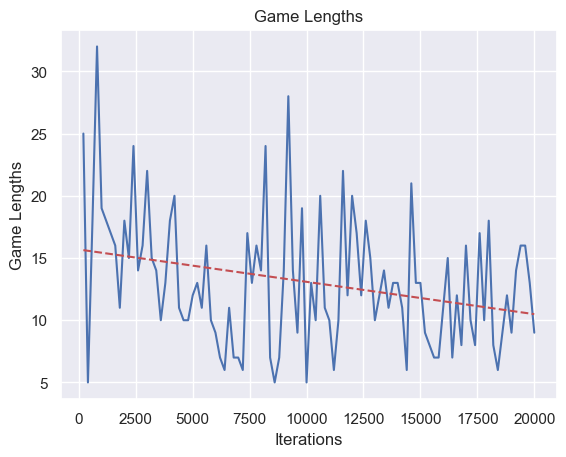

In [ ]:
# plot game lengths progression including trend line
game_lengths = training_log['game_lengths']
game_lengths.plot()
z = np.polyfit(game_lengths.index, game_lengths, 1)
p = np.poly1d(z)
plt.plot(game_lengths.index,p(game_lengths.index),"r--")
plt.xlabel('Iterations')
plt.ylabel('Game Lengths')
plt.title('Game Lengths')
plt.savefig(f'../images/game_lengths_progression_{version}.png')

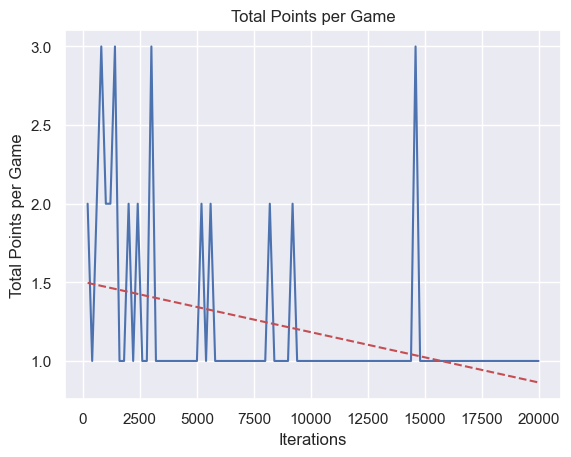

In [ ]:
# plot total points per game progression including trend line
total_points_per_game = training_log['total_points_per_game']
total_points_per_game.plot()
z = np.polyfit(total_points_per_game.index, total_points_per_game, 1)
p = np.poly1d(z)
plt.plot(total_points_per_game.index,p(total_points_per_game.index),"r--")
plt.xlabel('Iterations')
plt.ylabel('Total Points per Game')
plt.title('Total Points per Game')
plt.savefig(f'../images/total_points_per_game_progression_{version}.png')

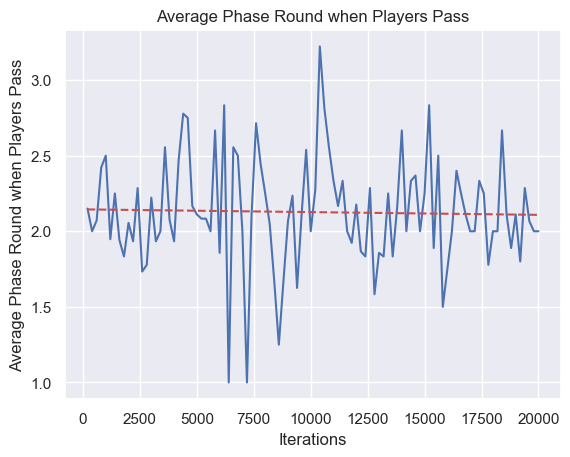

In [ ]:
# plot phase round when players pass progression including trend line
phase_round_when_players_pass = training_log['phase_round_when_players_pass']
phase_round_when_players_pass.plot()
z = np.polyfit(phase_round_when_players_pass.index, phase_round_when_players_pass, 1)
p = np.poly1d(z)
plt.plot(phase_round_when_players_pass.index,p(phase_round_when_players_pass.index),"r--")

plt.xlabel('Iterations')
plt.ylabel('Average Phase Round when Players Pass')
plt.title('Average Phase Round when Players Pass')
plt.savefig(f'../images/phase_round_when_players_pass_progression_{version}.png')

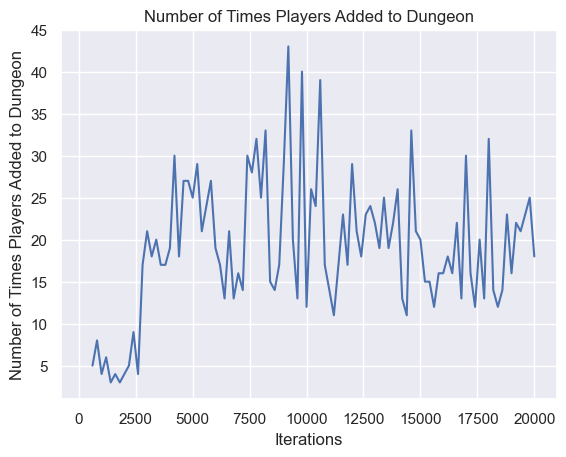

In [ ]:
# plot number of times players added to dungeon progression inclusing trend line
number_of_times_players_added_to_dungeon = training_log['number_of_times_players_added_to_dungeon']
number_of_times_players_added_to_dungeon.plot()
z = np.polyfit(number_of_times_players_added_to_dungeon.index, number_of_times_players_added_to_dungeon, 1)
p = np.poly1d(z)
plt.plot(number_of_times_players_added_to_dungeon.index,p(number_of_times_players_added_to_dungeon.index),"r--")
plt.xlabel('Iterations')
plt.ylabel('Number of Times Players Added to Dungeon')
plt.title('Number of Times Players Added to Dungeon')
plt.savefig(f'../images/number_of_times_players_added_to_dungeon_progression_{version}.png')


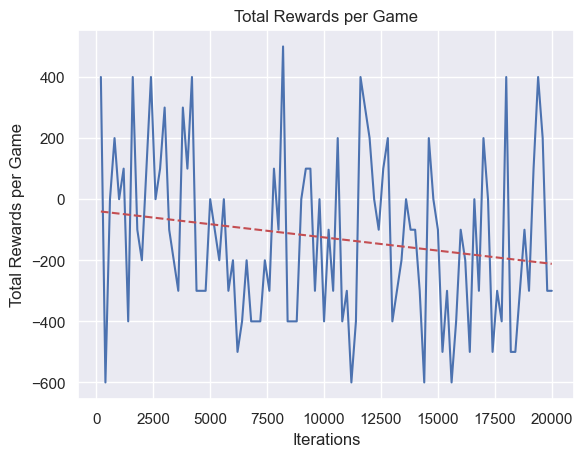

In [ ]:
# plot total rewards per game progression including trend line
total_rewards_per_game = training_log['total_rewards_per_game']
total_rewards_per_game.plot()
z = np.polyfit(total_rewards_per_game.index, total_rewards_per_game, 1)
p = np.poly1d(z)
plt.plot(total_rewards_per_game.index,p(total_rewards_per_game.index),"r--")
plt.xlabel('Iterations')
plt.ylabel('Total Rewards per Game')
plt.title('Total Rewards per Game')
plt.savefig(f'../images/total_rewards_per_game_progression_{version}.png')


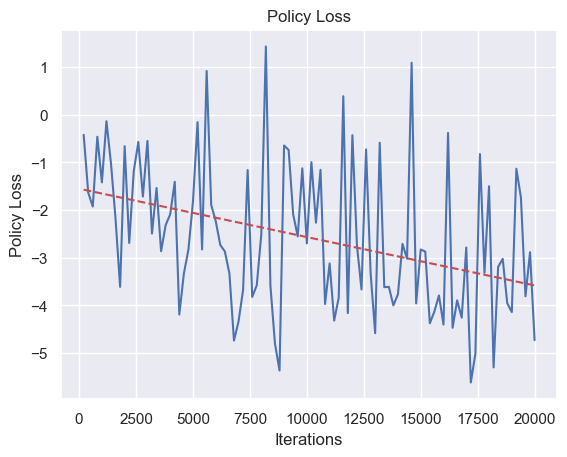

In [ ]:
# plot policy loss progression including trend line
policy_loss = training_log['policy_loss']
policy_loss.plot()
z = np.polyfit(policy_loss.index, policy_loss, 1)
p = np.poly1d(z)
plt.plot(policy_loss.index,p(policy_loss.index),"r--")
plt.xlabel('Iterations')
plt.ylabel('Policy Loss')
plt.title('Policy Loss')
plt.savefig(f'../images/policy_loss_progression_{version}.png')


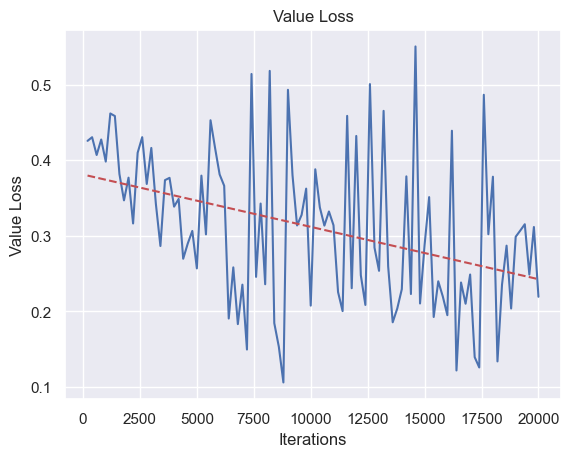

In [ ]:
# plot value loss progression
value_loss = training_log['value_loss']
value_loss.plot()
z = np.polyfit(value_loss.index, value_loss, 1)
p = np.poly1d(z)
plt.plot(value_loss.index,p(value_loss.index),"r--")
plt.xlabel('Iterations')
plt.ylabel('Value Loss')
plt.title('Value Loss')
plt.savefig(f'../images/value_loss_progression_{version}.png')